<a href="https://colab.research.google.com/github/AnnabelleMcSharry/AI-ML-Car-Data/blob/main/salesForcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [376]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

sales = pd.read_csv("sales training set.csv")

In [377]:
print("Missing values:\n", sales.isnull().sum())

# Check for duplicates
print("Duplicates:\n", sales.duplicated().sum())

# Count total number of rows
print("Total number of rows:", sales.shape[0])

Missing values:
 ProductID               0
Weight               1463
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize           2410
LocationType            0
OutletType              0
OutletSales             0
dtype: int64
Duplicates:
 0
Total number of rows: 8523


In [378]:
#analysis to see how much data would be lost if i just dropped all of the line swith missing values

new_sales = sales.dropna()

print("Total records that would be lost if deleted:")
print(sales.shape[0] - new_sales.shape[0])

#45% too high to just drop all values so will ahve to do further analysis
print("Percentage of records lost:")
print(((sales.shape[0] - new_sales.shape[0]) / sales.shape[0]) * 100)


Total records that would be lost if deleted:
3873
Percentage of records lost:
45.44174586413235


In [379]:
#counts how many times each outlet size appears including howmany times a missing value appears

print(sales["OutletSize"].value_counts(dropna=False))

#shows the percentage of each time the different outlet size occurs
#28% is too much to delete
print(sales["OutletSize"].value_counts(normalize=True, dropna=False) * 100)


OutletSize
Medium    2793
NaN       2410
Small     2388
High       932
Name: count, dtype: int64
OutletSize
Medium    32.770151
NaN       28.276428
Small     28.018303
High      10.935117
Name: proportion, dtype: float64


In [380]:
#checking to see if outlet size is linked to outlet type to see if i can fill in the values mnaually
print(pd.crosstab(sales["OutletType"], sales["OutletSize"], dropna=False))

#shows how many outlet types have missing values- all missiing values are in grocery store or supermarket type 1
#50% of super market type 1 is small
#grocery stores are all small if they ahve a value
print(pd.crosstab(sales["OutletType"], sales["OutletSize"].isnull()))



OutletSize         High  Medium  Small   NaN
OutletType                                  
Grocery Store         0       0    528   555
Supermarket Type1   932     930   1860  1855
Supermarket Type2     0     928      0     0
Supermarket Type3     0     935      0     0
OutletSize         False  True 
OutletType                     
Grocery Store        528    555
Supermarket Type1   3722   1855
Supermarket Type2    928      0
Supermarket Type3    935      0


In [381]:
#all known grocery stores are small so i will change them all to small
sales.loc[
    (sales["OutletType"] == "Grocery Store") & (sales["OutletSize"].isnull()),"OutletSize"] = "Small"

In [382]:
#because there is almost exact 25-25-50 split for supermarlet type 1 between high-medium-small i used this distribution to fill the missing values
import numpy as np

# Select missing Outlet_Size rows where Outlet_Type is Supermarket Type1
missing_type1 = ((sales["OutletType"] == "Supermarket Type1") &(sales["OutletSize"].isnull()))

# Calculate the existing size distribution for known Supermarket Type1 rows
type1_distribution = sales.loc[(sales["OutletType"] == "Supermarket Type1") &(sales["OutletSize"].notnull()),"OutletSize"].value_counts(normalize=True)

print(type1_distribution)

# Fill missing values using the same distribution
np.random.seed(42)

sales.loc[missing_type1, "OutletSize"] = np.random.choice(type1_distribution.index,size=missing_type1.sum(),p=type1_distribution.values)


OutletSize
Small     0.499731
High      0.250403
Medium    0.249866
Name: proportion, dtype: float64


In [383]:
print("Missing values:\n", sales.isnull().sum())

# Check for duplicates
print("Duplicates:\n", sales.duplicated().sum())

# Count total number of rows
print("Total number of rows:", sales.shape[0])


Missing values:
 ProductID               0
Weight               1463
FatContent              0
ProductVisibility       0
ProductType             0
MRP                     0
OutletID                0
EstablishmentYear       0
OutletSize              0
LocationType            0
OutletType              0
OutletSales             0
dtype: int64
Duplicates:
 0
Total number of rows: 8523


count    7060.000000
mean       12.857645
std         4.643456
min         4.555000
25%         8.773750
50%        12.600000
75%        16.850000
max        21.350000
Name: Weight, dtype: float64
Percentage of missing weights:
17.165317376510618


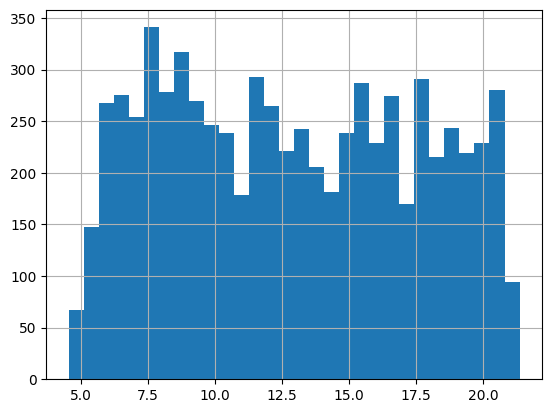

In [384]:
#looking at the distributions of the weight so i can try to figure out how to best deal with the missing data

print(sales["Weight"].describe())

sales["Weight"].hist(bins=30)

print("Percentage of missing weights:")
print((sales["Weight"].isnull().sum() / len(sales)) * 100)

#17% is missing a weight which is too high to delete

In [385]:
# Check whether missing Weight values can be filled using the same item sold in other stores

total_missing_weight_rows = sales["Weight"].isnull().sum()

unique_items_with_missing_weight = sales.loc[ sales["Weight"].isnull(), "ProductID"].nunique()

# Count how many known weight values each item has
known_weights_per_item = sales.groupby("ProductID")["Weight"].nunique()


items_with_known_weight = (known_weights_per_item > 0).sum()
items_with_no_known_weight = (known_weights_per_item == 0).sum()

print("Number of rows that do not have a weight", total_missing_weight_rows)
print("The number of unique items without a weight", unique_items_with_missing_weight)
print("Number of items with known weights in other stores", items_with_known_weight)
print("Number of items with no weight in the whole database", items_with_no_known_weight)



Number of rows that do not have a weight 1463
The number of unique items without a weight 1142
Number of items with known weights in other stores 1555
Number of items with no weight in the whole database 4


In [386]:
# Fill missing Weight values using the same item's known weight
sales["Weight"] = sales.groupby("ProductID")["Weight"].transform(lambda x: x.fillna(x.mean()))

# Check how many missing values are left
print("Missing Weight values remaining:")
print(sales["Weight"].isnull().sum())


Missing Weight values remaining:
4


In [387]:
#droppning the remaining items without a weight as i will only lose 20 records
sales = sales.dropna(subset=["Weight"])





In [388]:
#getting rid of the identifiers beacsue they are not factors that will help with regression they are descriptive

sales = sales.drop(columns=["ProductID", "OutletID"])
print(sales.head())
print(sales.columns)


   Weight FatContent  ProductVisibility            ProductType       MRP  \
0    9.30    Low Fat           0.016047                  Dairy  249.8092   
1    5.92    Regular           0.019278            Soft Drinks   48.2692   
2   17.50    Low Fat           0.016760                   Meat  141.6180   
3   19.20    Regular           0.000000  Fruits and Vegetables  182.0950   
4    8.93    Low Fat           0.000000              Household   53.8614   

   EstablishmentYear OutletSize LocationType         OutletType  OutletSales  
0               1999     Medium       Tier 1  Supermarket Type1    3735.1380  
1               2009     Medium       Tier 3  Supermarket Type2     443.4228  
2               1999     Medium       Tier 1  Supermarket Type1    2097.2700  
3               1998      Small       Tier 3      Grocery Store     732.3800  
4               1987       High       Tier 3  Supermarket Type1     994.7052  
Index(['Weight', 'FatContent', 'ProductVisibility', 'ProductType', 'M

In [389]:
#finding unique values before i encode
categorical_columns = ["FatContent", "ProductType", "OutletSize", "LocationType","OutletType"]

for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(sales[col].unique())



Unique values in FatContent:
['Low Fat' 'Regular' 'low fat' 'LF' 'reg']

Unique values in ProductType:
['Dairy' 'Soft Drinks' 'Meat' 'Fruits and Vegetables' 'Household'
 'Baking Goods' 'Snack Foods' 'Frozen Foods' 'Breakfast'
 'Health and Hygiene' 'Hard Drinks' 'Canned' 'Breads' 'Starchy Foods'
 'Others' 'Seafood']

Unique values in OutletSize:
['Medium' 'Small' 'High']

Unique values in LocationType:
['Tier 1' 'Tier 3' 'Tier 2']

Unique values in OutletType:
['Supermarket Type1' 'Supermarket Type2' 'Grocery Store'
 'Supermarket Type3']


In [390]:
#merging the fat content column as the labels all just mean regular or low fat
sales["FatContent"] = sales["FatContent"].replace({"LF": "Low Fat","low fat": "Low Fat","reg": "Regular" })

print(sales["FatContent"].unique())
print(sales["FatContent"].value_counts())


['Low Fat' 'Regular']
FatContent
Low Fat    5516
Regular    3003
Name: count, dtype: int64


In [391]:
#encoding fat content
sales = pd.get_dummies( sales, columns=["FatContent"], drop_first=True,  dtype=int)
print(sales.head())
print(sales.columns)

   Weight  ProductVisibility            ProductType       MRP  \
0    9.30           0.016047                  Dairy  249.8092   
1    5.92           0.019278            Soft Drinks   48.2692   
2   17.50           0.016760                   Meat  141.6180   
3   19.20           0.000000  Fruits and Vegetables  182.0950   
4    8.93           0.000000              Household   53.8614   

   EstablishmentYear OutletSize LocationType         OutletType  OutletSales  \
0               1999     Medium       Tier 1  Supermarket Type1    3735.1380   
1               2009     Medium       Tier 3  Supermarket Type2     443.4228   
2               1999     Medium       Tier 1  Supermarket Type1    2097.2700   
3               1998      Small       Tier 3      Grocery Store     732.3800   
4               1987       High       Tier 3  Supermarket Type1     994.7052   

   FatContent_Regular  
0                   0  
1                   1  
2                   0  
3                   1  
4       

In [392]:
#used one hot encoding for item type as there is only 16 categories
sales = pd.get_dummies(sales, columns=["ProductType"], drop_first=True, dtype=int)

print(sales.head())
print(sales.columns)


   Weight  ProductVisibility       MRP  EstablishmentYear OutletSize  \
0    9.30           0.016047  249.8092               1999     Medium   
1    5.92           0.019278   48.2692               2009     Medium   
2   17.50           0.016760  141.6180               1999     Medium   
3   19.20           0.000000  182.0950               1998      Small   
4    8.93           0.000000   53.8614               1987       High   

  LocationType         OutletType  OutletSales  FatContent_Regular  \
0       Tier 1  Supermarket Type1    3735.1380                   0   
1       Tier 3  Supermarket Type2     443.4228                   1   
2       Tier 1  Supermarket Type1    2097.2700                   0   
3       Tier 3      Grocery Store     732.3800                   1   
4       Tier 3  Supermarket Type1     994.7052                   0   

   ProductType_Breads  ...  ProductType_Fruits and Vegetables  \
0                   0  ...                                  0   
1               

In [393]:
#ordinal encoding for putlet size
outlet_size_order = {"Small": 0, "Medium": 1, "High": 2}

sales["OutletSize"] = sales["OutletSize"].map(outlet_size_order)

print(sales.head())
print(sales.columns)


   Weight  ProductVisibility       MRP  EstablishmentYear  OutletSize  \
0    9.30           0.016047  249.8092               1999           1   
1    5.92           0.019278   48.2692               2009           1   
2   17.50           0.016760  141.6180               1999           1   
3   19.20           0.000000  182.0950               1998           0   
4    8.93           0.000000   53.8614               1987           2   

  LocationType         OutletType  OutletSales  FatContent_Regular  \
0       Tier 1  Supermarket Type1    3735.1380                   0   
1       Tier 3  Supermarket Type2     443.4228                   1   
2       Tier 1  Supermarket Type1    2097.2700                   0   
3       Tier 3      Grocery Store     732.3800                   1   
4       Tier 3  Supermarket Type1     994.7052                   0   

   ProductType_Breads  ...  ProductType_Fruits and Vegetables  \
0                   0  ...                                  0   
1         

In [394]:
#ordinal encoding for location tiers
location_type_order = {"Tier 1": 0, "Tier 2": 1, "Tier 3": 2}
sales["LocationType"] = sales["LocationType"].map(location_type_order)
print(sales.head())
print(sales.columns)


   Weight  ProductVisibility       MRP  EstablishmentYear  OutletSize  \
0    9.30           0.016047  249.8092               1999           1   
1    5.92           0.019278   48.2692               2009           1   
2   17.50           0.016760  141.6180               1999           1   
3   19.20           0.000000  182.0950               1998           0   
4    8.93           0.000000   53.8614               1987           2   

   LocationType         OutletType  OutletSales  FatContent_Regular  \
0             0  Supermarket Type1    3735.1380                   0   
1             2  Supermarket Type2     443.4228                   1   
2             0  Supermarket Type1    2097.2700                   0   
3             2      Grocery Store     732.3800                   1   
4             2  Supermarket Type1     994.7052                   0   

   ProductType_Breads  ...  ProductType_Fruits and Vegetables  \
0                   0  ...                                  0   
1   

In [395]:
#one hot encoding for outlet thype
sales = pd.get_dummies(sales, columns=["OutletType"], drop_first=True, dtype=int)

print(sales.head())
print(sales.columns)


   Weight  ProductVisibility       MRP  EstablishmentYear  OutletSize  \
0    9.30           0.016047  249.8092               1999           1   
1    5.92           0.019278   48.2692               2009           1   
2   17.50           0.016760  141.6180               1999           1   
3   19.20           0.000000  182.0950               1998           0   
4    8.93           0.000000   53.8614               1987           2   

   LocationType  OutletSales  FatContent_Regular  ProductType_Breads  \
0             0    3735.1380                   0                   0   
1             2     443.4228                   1                   0   
2             0    2097.2700                   0                   0   
3             2     732.3800                   1                   0   
4             2     994.7052                   0                   0   

   ProductType_Breakfast  ...  ProductType_Household  ProductType_Meat  \
0                      0  ...                      0  

In [396]:
#chnaging the establishment year to be the number of years opened because that is more valuable data
#data set is based off 2013ndata so basing years opened on year opened at the time the data was taken

sales["OutletAge"] = 2013 - sales["EstablishmentYear"]
sales = sales.drop(columns=["EstablishmentYear"])

print(sales.head())
print(sales.columns)


   Weight  ProductVisibility       MRP  OutletSize  LocationType  OutletSales  \
0    9.30           0.016047  249.8092           1             0    3735.1380   
1    5.92           0.019278   48.2692           1             2     443.4228   
2   17.50           0.016760  141.6180           1             0    2097.2700   
3   19.20           0.000000  182.0950           0             2     732.3800   
4    8.93           0.000000   53.8614           2             2     994.7052   

   FatContent_Regular  ProductType_Breads  ProductType_Breakfast  \
0                   0                   0                      0   
1                   1                   0                      0   
2                   0                   0                      0   
3                   1                   0                      0   
4                   0                   0                      0   

   ProductType_Canned  ...  ProductType_Meat  ProductType_Others  \
0                   0  ...          

In [397]:
#need to use feature scaling as mrp (maximum retail price) is too high
#dont scale the sales as that is the goal

X = sales.drop(columns=["OutletSales"])
y = sales["OutletSales"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.03, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




In [398]:
#checking correlation for feature selection
correlations = sales.corr(numeric_only=True)["OutletSales"].sort_values(ascending=False)

print(correlations)


OutletSales                          1.000000
MRP                                  0.567803
OutletType_Supermarket Type3         0.311089
OutletSize                           0.173335
OutletType_Supermarket Type1         0.108919
LocationType                         0.089003
OutletAge                            0.049083
ProductType_Fruits and Vegetables    0.025981
ProductType_Snack Foods              0.022374
FatContent_Regular                   0.018974
ProductType_Household                0.015726
ProductType_Starchy Foods            0.015050
Weight                               0.013168
ProductType_Dairy                    0.008561
ProductType_Canned                   0.007406
ProductType_Seafood                  0.007387
ProductType_Breads                   0.002343
ProductType_Meat                    -0.002983
ProductType_Hard Drinks             -0.003948
ProductType_Breakfast               -0.004650
ProductType_Frozen Foods            -0.009329
ProductType_Others                

In [399]:
#predicting using everything apart from the sales (the target)
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)

y_pred = linear_model.predict(X_test_scaled)

print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))




Mean Squared Error: 1462966.3682706738
Root Mean Squared Error: 1209.5314664243647
R2 Score: 0.5573137911092485


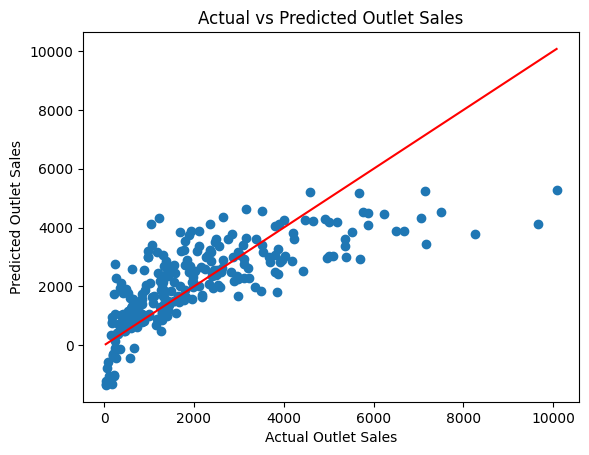

In [401]:
#visualise actual sales vs the predicted sales
#shows a general upwards trend but not fully on the line
#shows the model is underpredicting the higher sales
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual Outlet Sales")
plt.ylabel("Predicted Outlet Sales")
plt.title("Actual vs Predicted Outlet Sales")
plt.show()


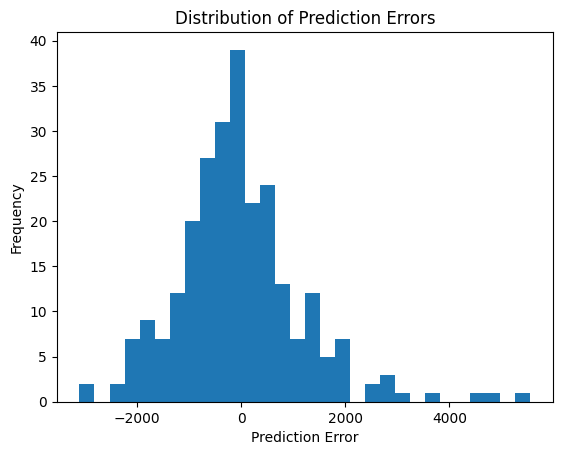

In [402]:
#show the prediction error and also shows that the graph often predcts too low
errors = y_test - y_pred

plt.hist(errors, bins=30)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()
